# Lab 04: The Scaling Relation That Depends on How You Fit It

**ASTR 457, Fall 2026, posted Thu Sep 24, due Wed Sep 30 by Noon (fork → PR, as always)**

**Extra credit, +5 points on this lab:** if you attended Charlotte Ward's Sep 22 Astronomy Colloquium, turn in at least a page of notes including two questions you had, as a text file in your `submissions/<netid>/` folder, by Noon Tue Sep 29.

*Why this lab: every scaling relation you will ever use ($M_{\rm BH}$–$\sigma$, Tully–Fisher, the mass–metallicity relation, the SN Ia standardization) was fit by someone who chose a regression method, and the choice changes the published slope. Knowing when ordinary least squares lies, by how much, and what to do instead is how you read those papers, and how you referee them.*

Every one of you has your own dataset: `data/<your netid>.csv`, a sample of dwarf
galaxies hosting active galactic nuclei, selected by their optical variability in the
style of Ward et al. (2022, arXiv:2110.13098). Dwarf-galaxy AGN are one of the few
windows we have on black holes in the $10^5$–$10^7\,M_\odot$ range, where the seeds of
supermassive black holes hide. Columns:

- `logMstar`, `err_logMstar`: $x = \log_{10}(M_*/M_\odot)$, the host stellar mass from
  SED fitting, and its $1\sigma$ uncertainty (0.2–0.4 dex; dwarf-galaxy photometry is hard),
- `logMBH`, `err_logMBH`: $y = \log_{10}(M_{\rm BH}/M_\odot)$, the virial black-hole
  mass from broad-line spectroscopy, and its $1\sigma$ uncertainty.

The relation you are after is

$$y = \alpha\,(x - 9.5) + \beta + \text{intrinsic scatter } \sigma_{\rm int},$$

pivoted at $M_* = 10^{9.5} M_\odot$ so $\alpha$ and $\beta$ don't fight each other. **Both
variables have measurement error, and the relation has real astrophysical scatter on top.**
I know your true $\alpha$, $\beta$, and $\sigma_{\rm int}$. You don't, your classmates'
values are different from yours, and so are your sample sizes.

**How this is graded.** Not on whether your code runs, but on whether your answers are
*right* and your uncertainties are *honest*. Part of your grade comes from how close your
reported $\alpha$ and $\beta$ are to your truth **in units of your own reported
uncertainty**. Tiny error bars you can't back up lose points; padded ones lose points too.
Calibration is the skill. The floor under "padded": your reported $\sigma_\alpha$ may not
exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
than that is not caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
from scipy import odr

NETID = 'ym31'
d = np.genfromtxt(f'../../labs/04/data/{NETID}.csv', delimiter=',', names=True)
x, sx = d['logMstar'], d['err_logMstar']
y, sy = d['logMBH'], d['err_logMBH']
N = len(x)
print(N, 'galaxies')
print('median sigma_x =', round(np.median(sx), 3), ' median sigma_y =', round(np.median(sy), 3))

59 galaxies
median sigma_x = 0.301  median sigma_y = 0.316


## Part 1: The fit everyone does first (15%)

Load your sample and plot it with error bars **on both axes**. Then fit the relation the
way most papers still do: **ordinary least squares** on $y$ vs $(x - 9.5)$, every point
weighted equally, errors ignored. Build the design matrix and solve the normal equations
yourself (lecture machinery, or `np.polyfit` if you must, but know what it's doing). Report
$\hat\alpha \pm \sigma$ using the standard OLS variance estimate, $s^2 (A^{\mathsf T}A)^{-1}$
with $s^2 = \mathrm{RSS}/(N-2)$ (residual-scaled; the errors play no role yet, on purpose).

Then answer, in a few sentences: which of OLS's assumptions does *your* dataset violate?
For the slope specifically, which way does the bias from the $x$-errors pull, and what
controls its size? (We named it in lecture on Sep 24. The effect is *supposed*
to be there; understanding exactly why, on your own data, is the point of this lab.)

OLS: alpha = 1.376 +/- 0.178
     beta  = 6.594 +/- 0.108
     s = 0.829 dex
rough sig_pop = 0.52 , R_x = 0.26


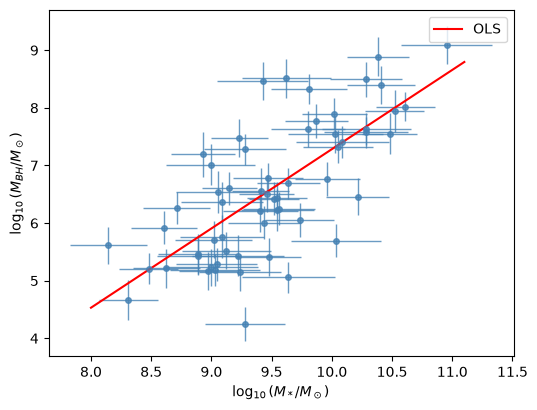

In [2]:
# Part 1: OLS with the normal equations
A = np.vstack([np.ones(N), x - 9.5]).T
AtA_inv = np.linalg.inv(A.T @ A)
th_ols = AtA_inv @ A.T @ y
resid = y - A @ th_ols
s2 = resid @ resid / (N - 2)
cov_ols = s2 * AtA_inv
b_ols, a_ols = th_ols
print('OLS: alpha =', round(a_ols, 3), '+/-', round(np.sqrt(cov_ols[1, 1]), 3))
print('     beta  =', round(b_ols, 3), '+/-', round(np.sqrt(cov_ols[0, 0]), 3))
print('     s =', round(np.sqrt(s2), 3), 'dex')

# how big should the attenuation be
Rx = np.mean(sx**2) / np.var(x)
sig_pop_rough = np.sqrt(np.var(x) - np.mean(sx**2))
print('rough sig_pop =', round(sig_pop_rough, 2), ', R_x =', round(Rx, 2))

xx = np.linspace(8, 11.1, 50)
plt.figure(figsize=(6, 4.5))
plt.errorbar(x, y, xerr=sx, yerr=sy, fmt='o', ms=4, color='steelblue', elinewidth=1, alpha=0.8)
plt.plot(xx, b_ols + a_ols * (xx - 9.5), 'r', label='OLS')
plt.xlabel(r'$\log_{10}(M_*/M_\odot)$')
plt.ylabel(r'$\log_{10}(M_{BH}/M_\odot)$')
plt.legend()
plt.show()

**ANSWER (a few sentences):**

OLS gives $\alpha$ = 1.38 +/- 0.18 and $\beta$ = 6.59 +/- 0.11. The main assumption my data breaks is that x is exact. The stellar masses have errors of 0.2-0.4 dex, which isn't that much smaller then the actual spread of the galaxies. OLS also weights every point the same even though they have different y errors, and there's no intrinsic scatter term so everything just goes into one s, which comes out a lot bigger than the y errors.

For the slope the x errors are the problem. Noise in x spreads the points out sideways but doesn't move them up or down, so the fitted line comes out flatter: $E[\hat\alpha_{OLS}] = \alpha\,\sigma_{pop}^2/(\sigma_{pop}^2 + \sigma_x^2)$. This is attenuation (regression dilution) and it always pulls the slope toward zero. How big it is depends on $\sigma_x$ compared to $\sigma_{pop}$, not on N, so more data wouldn't help. My $\sigma_x$ is around 0.3 and the x spread is about 0.6, so $R_x$ is about 0.26 and OLS should be low by a good amount.

## Part 2: Estimators you can defend (40%)

Now fit the relation **three more ways** and compare:

1. **Weighted least squares** using the $y$-errors only:
   $\hat{\theta} = (A^{\mathsf T}\Sigma^{-1}A)^{-1}A^{\mathsf T}\Sigma^{-1}y$ with
   $\Sigma = \mathrm{diag}(\sigma_{y,i}^2)$, parameter covariance
   $(A^{\mathsf T}\Sigma^{-1}A)^{-1}$. Does weighting fix the Part 1 bias? Why or why not?

2. **Orthogonal distance regression** (`scipy.odr`, which warns that it is deprecated on
   import; that is fine in the course environment), which knows about the $x$-errors.
   Read what it minimizes before you run it. What does ODR assume about scatter
   *perpendicular to the relation*, and is that assumption true here?

3. **The generative model, honestly.** Write down where each data point comes from:
   the true stellar masses are drawn from the population,
   $x_i^{\rm true} \sim \mathcal{N}(\mu, \sigma_{\rm pop}^2)$; the relation plus intrinsic scatter
   makes the true BH mass; and your measurement errors corrupt both. Marginalizing over
   the (unobservable) true masses makes each observed pair $(x_i, y_i)$ a **bivariate
   Gaussian**:

   $$\begin{pmatrix} x_i \\ y_i \end{pmatrix} \sim \mathcal{N}\!\left[
   \begin{pmatrix} \mu \\ \alpha(\mu - 9.5) + \beta \end{pmatrix},\;
   \begin{pmatrix} \sigma_{\rm pop}^2 + \sigma_{x,i}^2 & \alpha\,\sigma_{\rm pop}^2 \\
   \alpha\,\sigma_{\rm pop}^2 & \alpha^2\sigma_{\rm pop}^2 + \sigma_{\rm int}^2 + \sigma_{y,i}^2 \end{pmatrix}
   \right]$$

   (Convince yourself of the three variance entries before you code; the off-diagonal
   covariance is what removes the attenuation bias. This is the Gaussian core of Kelly 2007, the paper behind
   every modern `linmix`-style fit.) Maximize the summed log-likelihood over all five
   parameters $(\alpha, \beta, \sigma_{\rm int}, \mu, \sigma_{\rm pop})$, and get uncertainties from
   the curvature of the log-likelihood at its peak (the observed information), and say so.

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header.

In [3]:
# Part 2.1: WLS with the y errors only
def wls(A, y, sy):
    Si = np.diag(1 / sy**2)
    cov = np.linalg.inv(A.T @ Si @ A)
    return cov @ A.T @ Si @ y, cov

th_wls, cov_wls = wls(A, y, sy)
chi2_wls = np.sum(((y - A @ th_wls) / sy)**2)
print('WLS: alpha =', round(th_wls[1], 3), '+/-', round(np.sqrt(cov_wls[1, 1]), 3),
      ' beta =', round(th_wls[0], 3), '+/-', round(np.sqrt(cov_wls[0, 0]), 3))
print('     chi2/dof =', round(chi2_wls / (N - 2), 2))

# Part 2.2: ODR
def line(B, x):
    return B[0] * (x - 9.5) + B[1]

def run_odr(x, y, sx, sy):
    return odr.ODR(odr.RealData(x, y, sx=sx, sy=sy), odr.Model(line), beta0=[1.0, 6.5]).run()

out_odr = run_odr(x, y, sx, sy)
a_odr, b_odr = out_odr.beta
print('ODR: alpha =', round(a_odr, 3), '+/-', round(out_odr.sd_beta[0], 3),
      ' beta =', round(b_odr, 3), ' res_var =', round(out_odr.res_var, 2))

WLS: alpha = 1.371 +/- 0.067  beta = 6.573 +/- 0.04
     chi2/dof = 7.22
ODR: alpha = 2.171 +/- 0.233  beta = 6.6  res_var = 1.7


In [4]:
# Part 2.3: generative model, p = (alpha, beta, ln sig_int, mu, ln sig_pop)
def neg2logL(p, x, y, sx, sy):
    alpha, beta, lsi, mu, lsp = p
    si2 = np.exp(2 * lsi)
    sp2 = np.exp(2 * lsp)
    dx = x - mu
    dy = y - (alpha * (mu - 9.5) + beta)
    c11 = sp2 + sx**2
    c22 = alpha**2 * sp2 + si2 + sy**2
    c12 = alpha * sp2
    det = c11 * c22 - c12**2
    chi2 = (c22 * dx**2 - 2 * c12 * dx * dy + c11 * dy**2) / det
    return np.sum(np.log(det) + chi2)

def hessian(f, p, h=1e-4):
    n = len(p)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei = np.zeros(n)
            ej = np.zeros(n)
            ei[i] = h
            ej[j] = h
            H[i, j] = (f(p + ei + ej) - f(p + ei - ej) - f(p - ei + ej) + f(p - ei - ej)) / (4 * h**2)
    return H

NM = dict(xatol=1e-8, fatol=1e-8, maxiter=20000)

def fit_gen(x, y, sx, sy, p0=None):
    if p0 is None:
        Ak = np.vstack([np.ones(len(x)), x - 9.5]).T
        th = np.linalg.lstsq(Ak, y, rcond=None)[0]
        p0 = [th[1], th[0], np.log(0.3), x.mean(), np.log(x.std())]
    return minimize(neg2logL, p0, args=(x, y, sx, sy), method='Nelder-Mead', options=NM)

def gen_errors(p, x, y, sx, sy):
    H = hessian(lambda q: neg2logL(q, x, y, sx, sy), p)
    if np.linalg.det(H) <= 0:
        return np.full(len(p), np.nan)
    return np.sqrt(np.diag(2 * np.linalg.inv(H)))   # factor 2 because f is -2lnL not -lnL

res = fit_gen(x, y, sx, sy)
p_gen = res.x

err_gen = gen_errors(p_gen, x, y, sx, sy)

a_gen, b_gen = p_gen[0], p_gen[1]
sint_gen = np.exp(p_gen[2])
sint_err = sint_gen * err_gen[2]    # error on ln(sig_int) -> error on sig_int
print('GEN: alpha =', round(a_gen, 3), '+/-', round(err_gen[0], 3))
print('     beta  =', round(b_gen, 3), '+/-', round(err_gen[1], 3))
print('     sig_int =', round(sint_gen, 3), '+/-', round(sint_err, 3), 'dex')
print('     mu =', round(p_gen[3], 3), '+/-', round(err_gen[3], 3), ', sig_pop =', round(np.exp(p_gen[4]), 3))
print('3x cap:', round(3 * err_gen[0], 2))

GEN: alpha = 1.807 +/- 0.233
     beta  = 6.597 +/- 0.109
     sig_int = 0.55 +/- 0.12 dex
     mu = 9.495 +/- 0.081 , sig_pop = 0.541
3x cap: 0.7


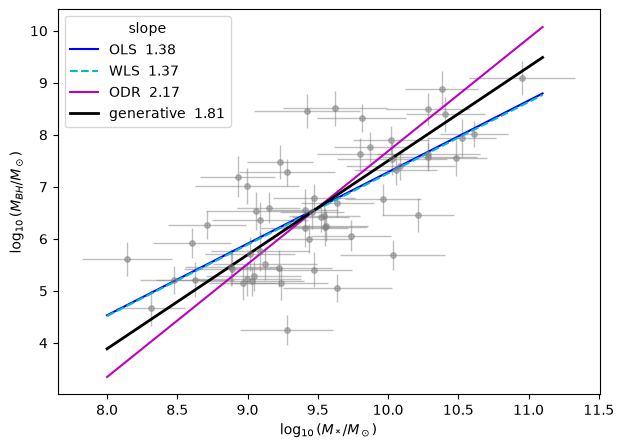

In [5]:
plt.figure(figsize=(7, 5))
plt.errorbar(x, y, xerr=sx, yerr=sy, fmt='o', ms=4, color='gray', elinewidth=1, alpha=0.5)
plt.plot(xx, b_ols + a_ols * (xx - 9.5), 'b', label=f'OLS  {a_ols:.2f}')
plt.plot(xx, th_wls[0] + th_wls[1] * (xx - 9.5), 'c', ls='--', label=f'WLS  {th_wls[1]:.2f}')
plt.plot(xx, b_odr + a_odr * (xx - 9.5), 'm', label=f'ODR  {a_odr:.2f}')
plt.plot(xx, b_gen + a_gen * (xx - 9.5), 'k', lw=2, label=f'generative  {a_gen:.2f}')
plt.xlabel(r'$\log_{10}(M_*/M_\odot)$')
plt.ylabel(r'$\log_{10}(M_{BH}/M_\odot)$')
plt.legend(title='slope')
plt.show()


In [6]:
print(f'alpha   = {a_gen:.2f} +/- {err_gen[0]:.2f}')
print(f'beta    = {b_gen:.2f} +/- {err_gen[1]:.2f}')
print(f'sig_int = {sint_gen:.2f} +/- {sint_err:.2f} dex')

alpha   = 1.81 +/- 0.23
beta    = 6.60 +/- 0.11
sig_int = 0.55 +/- 0.12 dex


**FINAL ANSWER:** $\alpha = $ 1.81 $\pm$ 0.23 (dimensionless), $\beta = $ 6.60 $\pm$ 0.11 , $\sigma_{\rm int} = $ 0.55 $\pm$ 0.12 dex

**Justification and uncertainty method (a short paragraph):**

The four lines don't agree. OLS (1.38) ignores the x errors so its attenuated like in Part 1. WLS (1.37) only uses the y errors, which doesn't fix anything about x, so the slope is pretty much the same as OLS. Its error bar is also way too small because it assumes $\sigma_y$ is the only scatter, and the $\chi^2$/dof is around 7 so there is a lot of intrinsic scatter that it's ignoring. ODR (2.17) does use the x errors but it assumes all the scatter is measurment error and none is intrinsic. Because it divides the residuals by $\sqrt{\sigma_y^2 + \alpha^2\sigma_x^2}$, a steeper line makes $\chi^2$ smaller, so it ends up too high. The generative model is the only one with both a population for the true x and intrinsic scatter. The off diagonal $\alpha\sigma_{pop}^2$ term is what tells it how much of the x spread is real, and it lands at 1.81, in between OLS and ODR.

I went with the generative fit. The errors are from the curvature of -2lnL at the best fit (numerical Hessian, cov = 2 H$^{-1}$). I fit ln($\sigma_{int}$) so the error on $\sigma_{int}$ is $\sigma_{int}$ times the error on ln($\sigma_{int}$). I didn't inflate the errors, the curvature ones are already under the 3x cap.

## Part 3: The verification plan, written first and then executed (35%)

**Before you run anything below, write the plan** (3a). A verification plan you invent
after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the generative recipe in
   Part 2 tells you exactly how) and confirm your fit recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot each estimator's bias and variance for $\alpha$. This is
   *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time, for all three reported parameters?
4. **Sensitivity**: what happens to $\hat\alpha$ if the catalog $x$-errors are wrong by
   ±50% (generate correctly, fit with the mis-stated errors)? If the true population isn't Gaussian (try drawing $x^{\rm true}$ from a uniform
   distribution with the same mean and variance instead)? If you had assumed $\sigma_{\rm int} = 0$?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

1. Closure: make a fake dataset from the generative model with parameters I pick ($\alpha$ = 1.5, $\beta$ = 6.5, $\sigma_{int}$ = 0.4, $\mu$ = 9.5, $\sigma_{pop}$ = 0.55) and my own error bars, and fit it like in Part 2. If a parameter comes back more than 2 sigma off something is wrong with the fit.
2. Bias and efficiency: 300 fake datasets at my best fit paramters, fit each one with all four methods and plot the $\alpha$ histograms and the bias with the std. I expect OLS and WLS to be low and ODR high. The generative one should be centered on the truth, if its not that's a failure.
3. Coverage: with the same sims, check how often the truth is inside the quoted 1 sigma for $\alpha$, $\beta$ and $\sigma_{int}$. It should be around 68%, if it's a lot lower the error bars are too small.
4. Sensitivity: fit sims with the x errors multiplied by 0.5 and 1.5, with $x^{true}$ drawn from a uniform distribution (same mean and variance), and with $\sigma_{int}$ fixed to 0. Then see how much the mean $\alpha$ moves compared to my error bar. If it moves by more than about 1 sigma my answer depends on that assumption.

In [7]:
# Part 3b.1: closure, one fake dataset with a truth I picked
rng = np.random.default_rng(31)
truth0 = {'alpha': 1.5, 'beta': 6.5, 'sig_int': 0.4, 'mu': 9.5, 'sig_pop': 0.55}

def fake_data(p, rng, xerr=sx, yerr=sy, flat=False):
    # draw true masses from the population, put them on the line, then add the measurement errors
    if flat:
        # uniform with the same variance: width**2 / 12 = sig_pop**2
        half = np.sqrt(12) * p['sig_pop'] / 2
        x_true = rng.uniform(p['mu'] - half, p['mu'] + half, len(xerr))
    else:
        x_true = rng.normal(p['mu'], p['sig_pop'], len(xerr))
    y_true = p['alpha'] * (x_true - 9.5) + p['beta'] + rng.normal(0, p['sig_int'], len(xerr))
    x_obs = x_true + rng.normal(0, xerr)
    y_obs = y_true + rng.normal(0, yerr)
    return x_obs, y_obs

xs, ys = fake_data(truth0, rng)
ps = fit_gen(xs, ys, sx, sy).x
es = gen_errors(ps, xs, ys, sx, sy)
got = [ps[0], ps[1], np.exp(ps[2]), ps[3], np.exp(ps[4])]
got_err = [es[0], es[1], np.exp(ps[2]) * es[2], es[3], np.exp(ps[4]) * es[4]]
for name, g, e in zip(truth0, got, got_err):
    print(name, ': true', truth0[name], ' fit', round(g, 3), '+/-', round(e, 3), ' z =', round((g - truth0[name]) / e, 2))

alpha : true 1.5  fit 1.715 +/- 0.227  z = 0.95
beta : true 6.5  fit 6.478 +/- 0.089  z = -0.24
sig_int : true 0.4  fit 0.322 +/- 0.133  z = -0.58
mu : true 9.5  fit 9.46 +/- 0.075  z = -0.54
sig_pop : true 0.55  fit 0.491 +/- 0.062  z = -0.95


OLS mean alpha 1.371  bias -0.436  std 0.165
WLS mean alpha 1.369  bias -0.438  std 0.168
ODR mean alpha 2.251  bias 0.445  std 0.268
generative mean alpha 1.837  bias 0.03  std 0.243


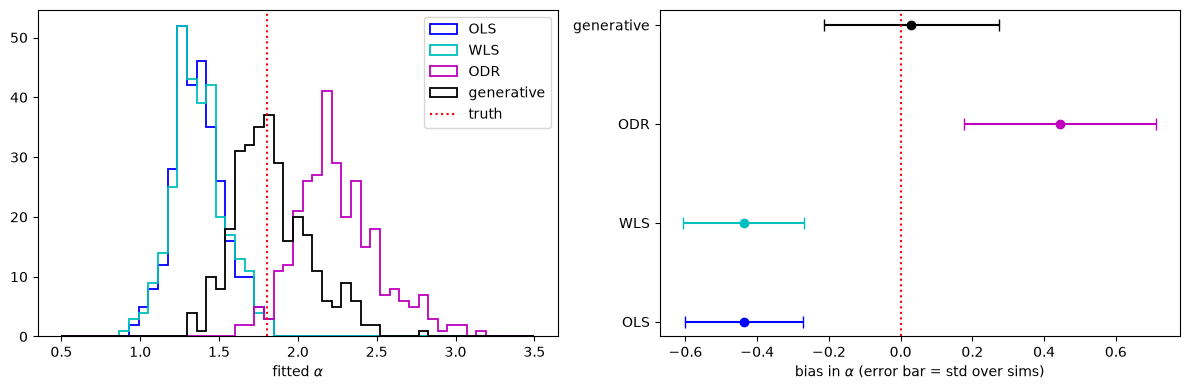

In [8]:
# Part 3b.2 and 3b.3: Monte Carlo of all four estimators at my fitted parameters
truth = dict(zip(truth0.keys(), [a_gen, b_gen, sint_gen, p_gen[3], np.exp(p_gen[4])]))
rng = np.random.default_rng(457)
nsim = 300
rows = []
for k in range(nsim):
    xs, ys = fake_data(truth, rng)
    Ak = np.vstack([np.ones(N), xs - 9.5]).T
    th = np.linalg.lstsq(Ak, ys, rcond=None)[0]
    r = ys - Ak @ th
    s_ols = np.sqrt(r @ r / (N - 2) * np.linalg.inv(Ak.T @ Ak)[1, 1])
    tw, cw = wls(Ak, ys, sy)
    o = run_odr(xs, ys, sx, sy)
    pk = fit_gen(xs, ys, sx, sy).x
    ek = gen_errors(pk, xs, ys, sx, sy)
    rows.append([th[1], s_ols, tw[1], np.sqrt(cw[1, 1]), o.beta[0], o.sd_beta[0],
                 pk[0], ek[0], pk[1], ek[1], np.exp(pk[2]), np.exp(pk[2]) * ek[2]])
mc = np.array(rows)

names = ['OLS', 'WLS', 'ODR', 'generative']
bias = [np.mean(mc[:, 2 * i]) - truth['alpha'] for i in range(4)]
sd = [np.std(mc[:, 2 * i]) for i in range(4)]
for i in range(4):
    print(names[i], 'mean alpha', round(np.mean(mc[:, 2*i]), 3), ' bias', round(bias[i], 3), ' std', round(sd[i], 3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
bins = np.linspace(0.5, 3.5, 50)
cols = ['b', 'c', 'm', 'k']
for i in range(4):
    ax[0].hist(mc[:, 2 * i], bins, histtype='step', lw=1.3, color=cols[i], label=names[i])
ax[0].axvline(truth['alpha'], color='r', ls=':', label='truth')
ax[0].set_xlabel(r'fitted $\alpha$')
ax[0].legend()
for i in range(4):
    ax[1].errorbar(bias[i], i, xerr=sd[i], fmt='o', color=cols[i], capsize=4)
ax[1].axvline(0, color='r', ls=':')
ax[1].set_yticks(range(4))
ax[1].set_yticklabels(names)
ax[1].set_xlabel(r'bias in $\alpha$ (error bar = std over sims)')
plt.tight_layout()
plt.show()

In [9]:
# coverage: how often is the truth inside the quoted 1 sigma
ok = np.all(np.isfinite(mc), axis=1)
m = mc[ok]
print('generative alpha  :', round(np.mean(np.abs(m[:, 6] - truth['alpha']) < m[:, 7]), 3))
print('generative beta   :', round(np.mean(np.abs(m[:, 8] - truth['beta']) < m[:, 9]), 3))
print('generative sig_int:', round(np.mean(np.abs(m[:, 10] - truth['sig_int']) < m[:, 11]), 3))


generative alpha  : 0.698
generative beta   : 0.661
generative sig_int: 0.668


correct : mean alpha 1.825 , shift 0.019
half x errors : mean alpha 1.444 , shift -0.363
1.5 times x errors : mean alpha 2.433 , shift 0.626
uniform x_true : mean alpha 1.842 , shift 0.035
sig_int = 0 : mean alpha 2.288 , shift 0.481


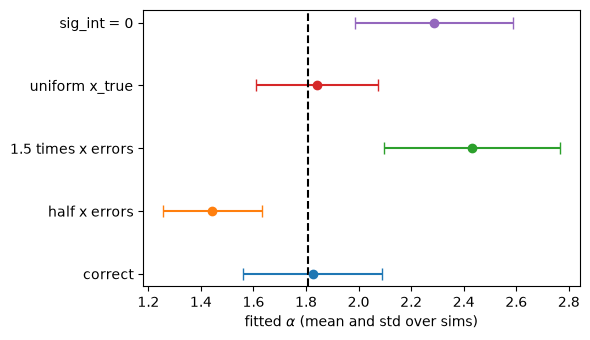

In [10]:
# Part 3b.4: sensitivity
def neg2logL_noscatter(q, x, y, sx, sy):
    # same likelihood with sig_int = 0, only 4 parameters (alpha, beta, mu, ln sig_pop)
    alpha, beta, mu, lsp = q
    sp2 = np.exp(2 * lsp)
    dx = x - mu
    dy = y - (alpha * (mu - 9.5) + beta)
    c11 = sp2 + sx**2
    c22 = alpha**2 * sp2 + sy**2
    c12 = alpha * sp2
    det = c11 * c22 - c12**2
    return np.sum(np.log(det) + (c22 * dx**2 - 2 * c12 * dx * dy + c11 * dy**2) / det)

def fit_nosint(x, y, sx, sy):
    start = [p_gen[0], p_gen[1], p_gen[3], p_gen[4]]
    return minimize(neg2logL_noscatter, start, args=(x, y, sx, sy), method='Nelder-Mead', options=NM).x

rng = np.random.default_rng(2026)
nsens = 150
sens = {'correct': [], 'half x errors': [], '1.5 times x errors': [], 'uniform x_true': [], 'sig_int = 0': []}
for k in range(nsens):
    xs, ys = fake_data(truth, rng)
    sens['correct'].append(fit_gen(xs, ys, sx, sy).x[0])
    sens['half x errors'].append(fit_gen(xs, ys, 0.5 * sx, sy).x[0])
    sens['1.5 times x errors'].append(fit_gen(xs, ys, 1.5 * sx, sy).x[0])
    sens['sig_int = 0'].append(fit_nosint(xs, ys, sx, sy)[0])
    xu, yu = fake_data(truth, rng, flat=True)
    sens['uniform x_true'].append(fit_gen(xu, yu, sx, sy).x[0])

for key in sens:
    v = np.array(sens[key])
    print(key, ': mean alpha', round(v.mean(), 3), ', shift', round(v.mean() - truth['alpha'], 3))


plt.figure(figsize=(6, 3.5))
keys = list(sens)
for i, key in enumerate(keys):
    v = np.array(sens[key])
    plt.errorbar(v.mean(), i, xerr=v.std(), fmt='o', capsize=4)
plt.axvline(truth['alpha'], color='k', ls='--')
plt.yticks(range(len(keys)), keys)
plt.xlabel(r'fitted $\alpha$ (mean and std over sims)')
plt.tight_layout()
plt.show()

**WHAT THE CHECKS FOUND:**

1. Closure passed, all five parameters came back within 1 sigma of the the truth ($\alpha$ = 1.72 +/- 0.23 for a true 1.5).

2. OLS and WLS both average about 1.37 so they're biased low by around 0.44, and ODR is biased high by about the same amount (2.25). The generative fit averages 1.84, only a little above the truth and way less than its spread. Its spread is bigger than OLS but since the other three are all off by ~0.4 its still clearly the best one.

3. Coverage for the generative fit was 0.70 for $\alpha$, 0.66 for $\beta$ and 0.67 for $\sigma_{int}$, so all close to 68% and the curvature errors seem fine.

4. The uniform population barely changed anything (1.84), so the gaussian assumption isn't a big deal here. Setting $\sigma_{int}$ = 0 moved it up to 2.29, which makes sense because then it's basically ODR. The x errors are the one that really matters. Fitting with 0.5x the errors gave 1.44 and 1.5x gave 2.43, which is more than my error bar both ways. So the answer is only as good as the catalog x errors, and I don't think I can check them from the data. I'm assuming they're right like the lab says, but it's a systematic that isn't in my error bar.

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true.

**AI-USE APPENDIX:**

I used Claude Code for this lab. I made sure I understood the problem first, then guided the AI to write the code and a first draft of the text, and checked its results against what I expected from the attenuation argument. It wasn't sure if the scipy ODR sd_beta already includes the res_var factor, so I checked and it does. It also left a comment about code that had been removed, which I caught reading through.